In [413]:
import numpy as np
import pandas as pd

In [414]:
df=pd.read_csv('spam.csv',encoding='latin-1')

In [415]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
2627,ham,I know I'm lacking on most of this particular ...,NaN,NaN,NaN
4830,ham,Po de :-):):-):-):-). No need job aha.,NaN,NaN,NaN
4627,spam,Todays Voda numbers ending with 7634 are selec...,NaN,NaN,NaN
366,spam,"Update_Now - Xmas Offer! Latest Motorola, Sony...",NaN,NaN,NaN
863,ham,Did u find out what time the bus is at coz i n...,NaN,NaN,NaN


In [416]:
df.shape

(5572, 5)

## Data Cleaning

In [418]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [419]:
# drop last 3 cols
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True)

In [420]:
df.sample(5)

,v1,v2
5204,ham,How come she can get it? Should b quite diff t...
5125,ham,After my work ah... Den 6 plus lor... U workin...
4933,ham,Hey do you want anything to buy:)
1631,ham,We not watching movie already. Xy wants 2 shop...
2969,ham,U should make a fb list


In [421]:
# renaming Columns
df.rename(columns={'v1':'target','v2':'sms'},inplace=True)

In [422]:
df.sample(5)

,target,sms
5530,ham,I think that tantrum's finished so yeah I'll b...
5183,ham,"Fuuuuck I need to stop sleepin, sup"
4022,ham,Well. Balls. Time to make calls
1837,ham,And how's your husband.
977,ham,Dont hesitate. You know this is the second tim...


In [423]:
from sklearn.preprocessing import LabelEncoder

In [424]:
encoder=LabelEncoder()

In [425]:
df['target']=encoder.fit_transform(df['target'])

In [426]:
df.head()

,target,sms
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [427]:
## missing values
df.isnull().sum()

target    0
sms       0
dtype: int64

In [428]:
# duplicate values
df.duplicated().sum()

403

In [429]:
# removing duplicates
df=df.drop_duplicates(keep='first')

In [430]:
df.duplicated().sum()

0

## EDA

In [432]:
import matplotlib.pyplot as plt

In [433]:
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

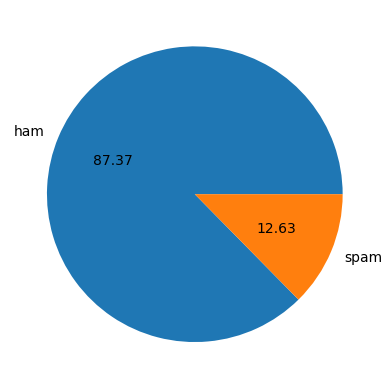

In [434]:
plt.pie(df['target'].value_counts(),labels=['ham','spam'],autopct='%.2f')
plt.show()

In [435]:
# Data is imbalanced

In [436]:
import nltk

In [437]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\thulu\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [438]:
# no of characters in each sms
df['num_characters']=df['sms'].apply(len)

In [439]:
df.head()

,target,sms,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [440]:

nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\thulu\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [441]:
# num of words
df['sms'].apply(lambda x : nltk.word_tokenize(x))

0       [Go, until, jurong, point, ,, crazy, .., Avail...
1                [Ok, lar, ..., Joking, wif, u, oni, ...]
2       [Free, entry, in, 2, a, wkly, comp, to, win, F...
3       [U, dun, say, so, early, hor, ..., U, c, alrea...
4       [Nah, I, do, n't, think, he, goes, to, usf, ,,...
                              ...                        
5567    [This, is, the, 2nd, time, we, have, tried, 2,...
5568     [Will, Ì_, b, going, to, esplanade, fr, home, ?]
5569    [Pity, ,, *, was, in, mood, for, that, ., So, ...
5570    [The, guy, did, some, bitching, but, I, acted,...
5571                  [Rofl, ., Its, true, to, its, name]
Name: sms, Length: 5169, dtype: object

In [442]:
df['sms'].apply(lambda x : len(nltk.word_tokenize(x)))

0       24
1        8
2       37
3       13
4       15
        ..
5567    35
5568     9
5569    15
5570    27
5571     7
Name: sms, Length: 5169, dtype: int64

In [443]:
df['num_words']=df['sms'].apply(lambda x : len(nltk.word_tokenize(x)))

In [444]:
df.head()

,target,sms,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [445]:
# no of sentences
df['sms'].apply(lambda x : nltk.sent_tokenize(x))

0       [Go until jurong point, crazy.., Available onl...
1                        [Ok lar..., Joking wif u oni...]
2       [Free entry in 2 a wkly comp to win FA Cup fin...
3       [U dun say so early hor... U c already then sa...
4       [Nah I don't think he goes to usf, he lives ar...
                              ...                        
5567    [This is the 2nd time we have tried 2 contact ...
5568              [Will Ì_ b going to esplanade fr home?]
5569    [Pity, * was in mood for that., So...any other...
5570    [The guy did some bitching but I acted like i'...
5571                        [Rofl., Its true to its name]
Name: sms, Length: 5169, dtype: object

In [446]:
df['num_sentences']=df['sms'].apply(lambda x : len(nltk.sent_tokenize(x)))

In [447]:
df.head()

,target,sms,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [448]:
df[['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [449]:
# ham messages
df[df['target']==0][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [450]:
# spam messages
df[df['target']==1][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [451]:
import seaborn as sns

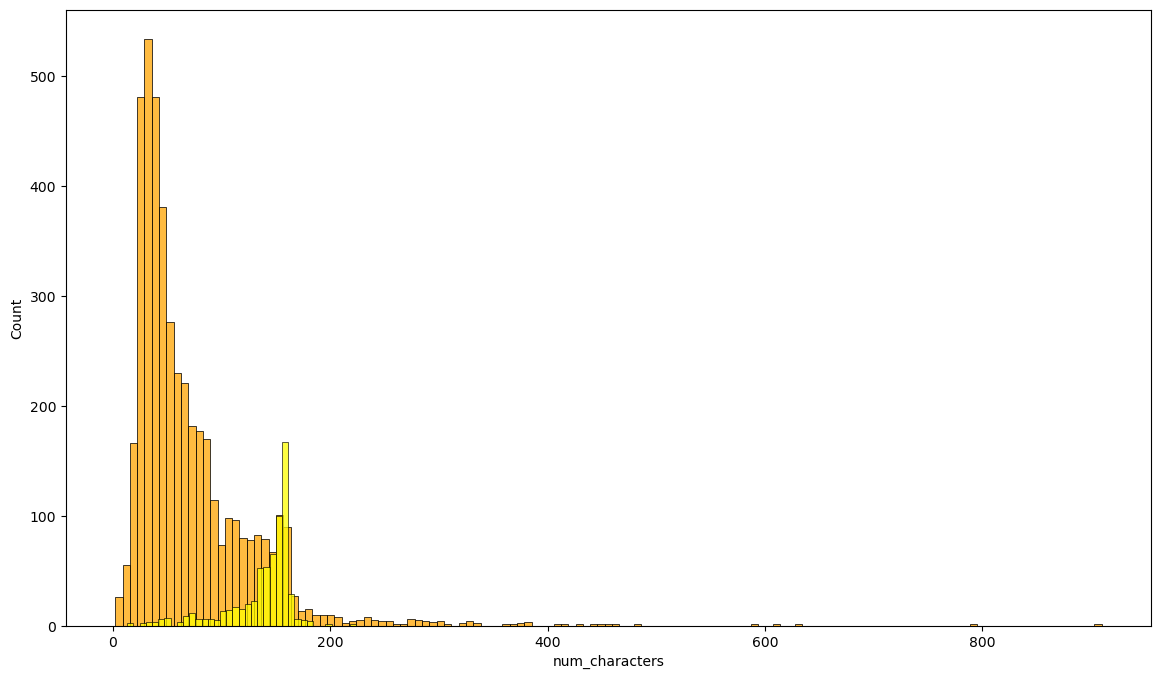

In [452]:
plt.figure(figsize=(14,8))
sns.histplot(df[df['target']==0]['num_characters'],color='orange')
sns.histplot(df[df['target']==1]['num_characters'],color='yellow')
plt.show()
# More ham messages are made of less no of characters 
# whereas most spam messages are made of more characters

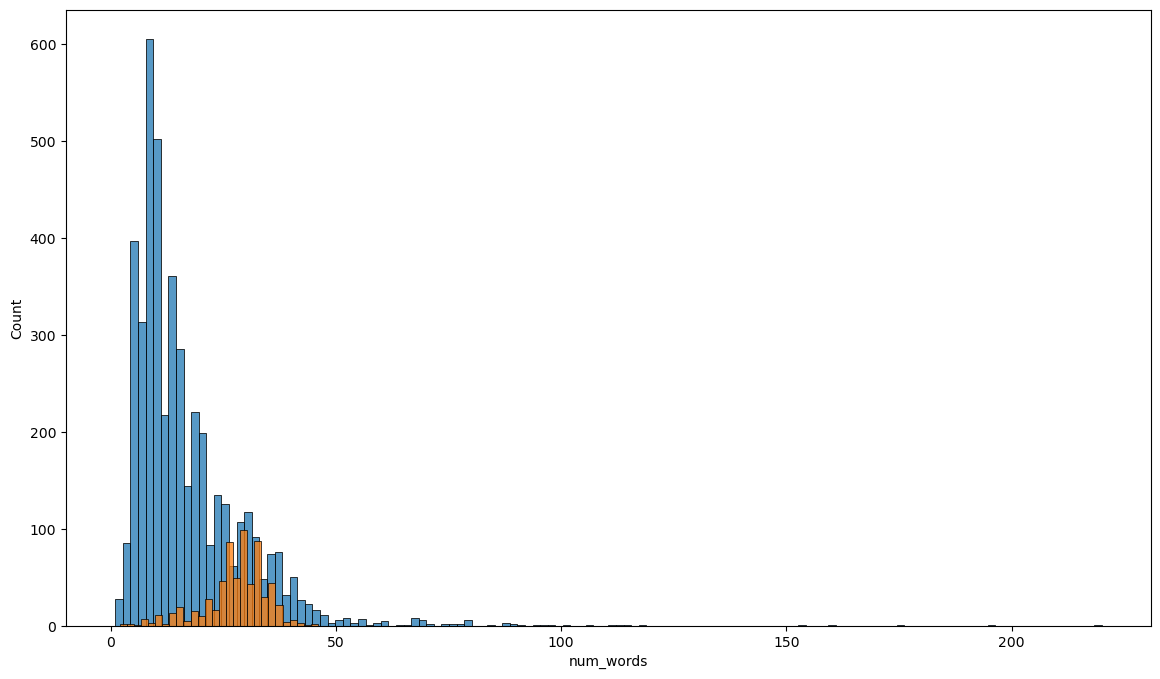

In [453]:
plt.figure(figsize=(14,8))
sns.histplot(df[df['target']==0]['num_words'])
sns.histplot(df[df['target']==1]['num_words'])
plt.show()
# ham less words
# spam messages

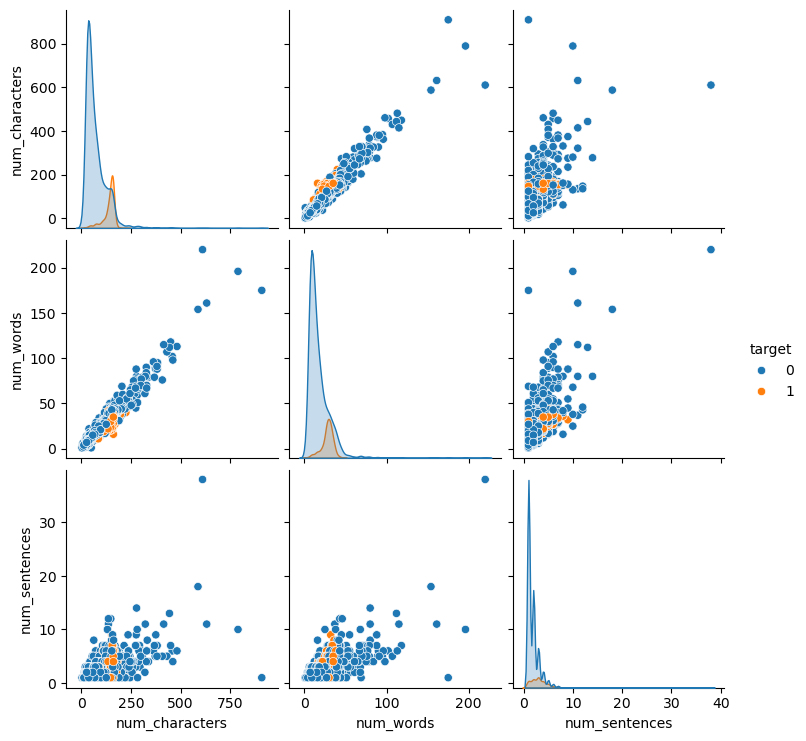

In [454]:
sns.pairplot(df,hue='target')
plt.show()

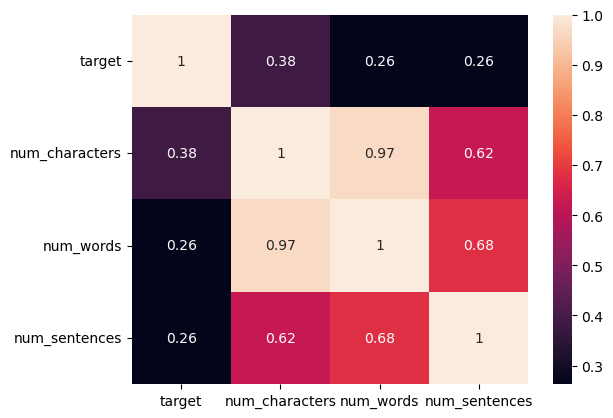

In [455]:
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.show()
# since there is a high correlation between num_chars,num_words and num_sentences
# we'll only keep one i.e num_characters since it has high correlation with target

## Text Preprocessing
##### lower case
##### Tokenization
##### Removing special characters
##### removing stop words and punctuation
##### Stemming : Stemming is the process of reducing words to their root/base form by chopping off prefixes or suffixes.Example: “playing”, “played”, “plays” → “play”.

In [457]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\thulu\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [458]:
from nltk.corpus import stopwords
stopwords.words('english')
# stopwords : They help to form sentence but have no real meaning in the sentence

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [459]:
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [460]:
from nltk.stem.porter import PorterStemmer
ps=PorterStemmer()
ps.stem('dancing')

'danc'

In [461]:
def transform_text(text):
    
    # 1. Convert to lowercase
    text = text.lower()
    
    # 2. Tokenization
    tokens = nltk.word_tokenize(text)
    
    # 3. Remove punctuation and special characters
    tokens = [word for word in tokens if word.isalnum()]
    
    # 4. Remove stopwords
    stop_words = set(stopwords.words('english'))# set for fast membership checking O(1) compared to lists O(n)
    tokens = [word for word in tokens if word not in stop_words]
    
    # 5. Stemming
    tokens = [ps.stem(word) for word in tokens]
    
    return " ".join(tokens)

In [462]:
df['sms'].apply(transform_text)

0       go jurong point crazi avail bugi n great world...
1                                   ok lar joke wif u oni
2       free entri 2 wkli comp win fa cup final tkt 21...
3                     u dun say earli hor u c alreadi say
4                    nah think goe usf live around though
                              ...                        
5567    2nd time tri 2 contact u pound prize 2 claim e...
5568                                b go esplanad fr home
5569                                    piti mood suggest
5570    guy bitch act like interest buy someth els nex...
5571                                       rofl true name
Name: sms, Length: 5169, dtype: object

In [463]:
df['processed_text']=df['sms'].apply(transform_text)

In [464]:
df.head()

,target,sms,num_characters,num_words,num_sentences,processed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [465]:
# Wordcloud
from wordcloud import WordCloud
wc=WordCloud(width=300,height=300,min_font_size=10,background_color='white')

In [466]:
spam_wc=wc.generate(df[df['target']==1]['processed_text'].str.cat(sep=" ")) # returns object
# .str.cat(sep=" ")) -> Combine all the strings, putting a space between each one.

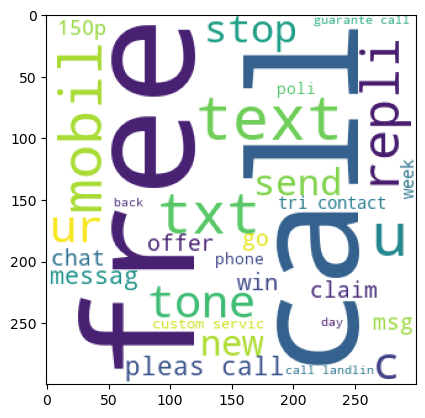

In [467]:
plt.imshow(spam_wc)
plt.show()

In [468]:
ham_wc=wc.generate(df[df['target']==0]['processed_text'].str.cat(sep=" "))

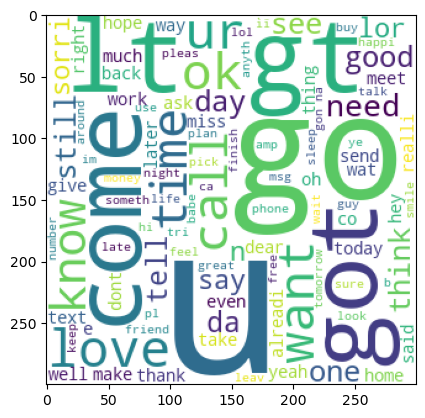

In [469]:
plt.imshow(ham_wc)
plt.show()

In [470]:
# top 30 words in both categories
spam_corpus=[]
for msg in df[df['target']==1]['processed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)
    

In [471]:
len(spam_corpus)# total words in spam 

9939

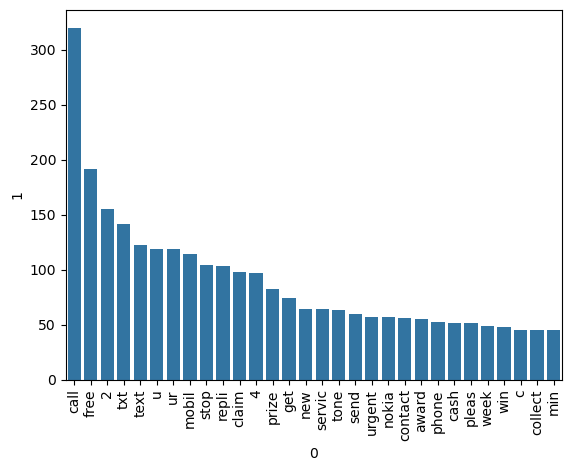

In [472]:
from collections import Counter
sns.barplot(x=pd.DataFrame(Counter(spam_corpus).most_common(30))[0],y=pd.DataFrame(Counter(spam_corpus).most_common(30))[1])
plt.xticks(rotation='vertical')
plt.show()

In [473]:
ham_corpus=[]
for msg in df[df['target']==0]['processed_text'].tolist():
    for word in msg.split():
        ham_corpus.append(word)

In [474]:
len(ham_corpus)

35404

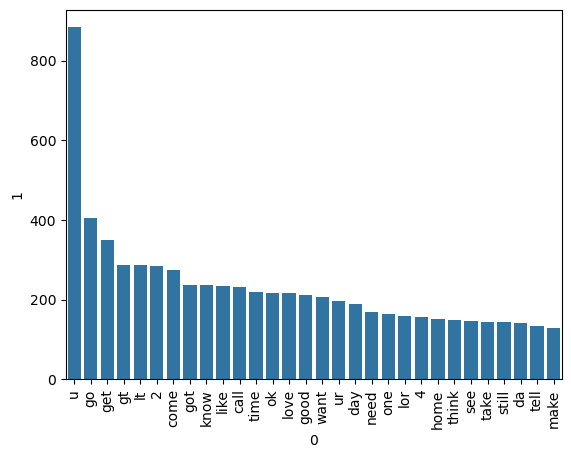

In [475]:
sns.barplot(x=pd.DataFrame(Counter(ham_corpus).most_common(30))[0],y=pd.DataFrame(Counter(ham_corpus).most_common(30))[1])
plt.xticks(rotation='vertical')
plt.show()

# Model Building

In [477]:
# vectorization
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer

In [478]:
cv=CountVectorizer()
tfidf=TfidfVectorizer(max_features=3000)

In [479]:
X=tfidf.fit_transform(df['processed_text']).toarray()

In [480]:
X

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [481]:
y=df['target'].values

In [482]:
X.shape

(5169, 3000)

In [483]:
from sklearn.model_selection import train_test_split

In [484]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [485]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

In [486]:
gnb=GaussianNB()
mnb=MultinomialNB()
bnb=BernoulliNB()

In [487]:
gnb.fit(X_train,y_train)
y_pred1=gnb.predict(X_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))

0.8607350096711799
[[769 120]
 [ 24 121]]
0.5020746887966805


In [488]:
mnb.fit(X_train,y_train)
y_pred2=mnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

0.9729206963249516
[[888   1]
 [ 27 118]]
0.9915966386554622


In [489]:
bnb.fit(X_train,y_train)
y_pred3=bnb.predict(X_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))

0.9729206963249516
[[884   5]
 [ 23 122]]
0.9606299212598425


In [490]:
# we choose tfidf and MNB

In [491]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [492]:
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2,algorithm='SAMME')
bc = BaggingClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50,random_state=2)
xgb = XGBClassifier(n_estimators=50,random_state=2)

In [493]:
clfs = {
    'SVC' : svc,
    'KN' : knc, 
    'NB': mnb, 
    'DT': dtc, 
    'LR': lrc, 
    'RF': rfc, 
    'AdaBoost': abc, 
    'BgC': bc, 
    'GBDT':gbdt,
    'xgb':xgb
}

In [494]:
def train_classifier(clf,X_train,y_train,X_test,y_test):
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)
    
    return accuracy,precision

In [495]:
import time
accuracy_scores = []
precision_scores = []
start=time.time()
for name,clf in clfs.items():
    
    current_accuracy,current_precision = train_classifier(clf, X_train,y_train,X_test,y_test)
    
    print("For ",name)
    print("Accuracy - ",current_accuracy)
    print("Precision - ",current_precision)
    
    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)
print('Time Taken :',time.time()-start)

For  SVC
Accuracy -  0.97678916827853
Precision -  0.9548872180451128
For  KN
Accuracy -  0.9042553191489362
Precision -  1.0
For  NB
Accuracy -  0.9729206963249516
Precision -  0.9915966386554622
For  DT
Accuracy -  0.9342359767891683
Precision -  0.8347826086956521
For  LR
Accuracy -  0.9468085106382979
Precision -  0.8688524590163934
For  RF
Accuracy -  0.971953578336557
Precision -  0.9754098360655737
For  AdaBoost
Accuracy -  0.9158607350096711
Precision -  0.8085106382978723
For  BgC
Accuracy -  0.9622823984526112
Precision -  0.8840579710144928
For  GBDT
Accuracy -  0.9468085106382979
Precision -  0.96875
For  xgb
Accuracy -  0.9622823984526112
Precision -  0.9344262295081968
Time Taken : 327.2128963470459


In [496]:
performance_df=pd.DataFrame({'Model':clfs.keys(),'Accuracy':accuracy_scores,'Precision':precision_scores}).sort_values('Precision',ascending=False)

In [497]:
performance_df

,Model,Accuracy,Precision
1,KN,0.904255,1.000000
2,NB,0.972921,0.991597
5,RF,0.971954,0.975410
8,GBDT,0.946809,0.968750
0,SVC,0.976789,0.954887
9,xgb,0.962282,0.934426
7,BgC,0.962282,0.884058
4,LR,0.946809,0.868852
3,DT,0.934236,0.834783
6,AdaBoost,0.915861,0.808511


# Improving Model Performance

In [582]:
from sklearn.ensemble import VotingClassifier

In [588]:
voting=VotingClassifier(estimators=[('NB', bnb), ('RF', rfc), ('MNB',mnb )],voting='soft')

In [590]:
voting.fit(X_train,y_train)

VotingClassifier(estimators=[('NB', BernoulliNB()),
                             ('RF',
                              RandomForestClassifier(n_estimators=50,
                                                     random_state=2)),
                             ('MNB', MultinomialNB())],
                 voting='soft')

In [592]:
y_pred = voting.predict(X_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))

Accuracy 0.9758220502901354
Precision 0.9918032786885246


In [594]:
from sklearn.ensemble import StackingClassifier

In [596]:
estimators=[('NB', bnb), ('RF', rfc), ('MNB',mnb )]
final_estimator=KNeighborsClassifier()

In [598]:
clf = StackingClassifier(estimators=estimators, final_estimator=final_estimator)

In [600]:
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))

Accuracy 0.9806576402321083
Precision 0.9629629629629629


In [602]:
import pickle
pickle.dump(tfidf,open('vectorizer.pkl','wb'))
pickle.dump(voting,open('model.pkl','wb'))